$ \textbf{Aluna:}$ Alessandra da Silva Dias Malizia   
$ \textbf{Data:}$ 12/07/2025

# Lista Prática 1

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import scipy.stats as stats
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import yfinance as yf
from arch import arch_model
import pandas as pd

# 1) Simulações

In [2]:
rng = np.random.default_rng(seed=4)

$$
\begin{align*}
y_{t|t-1} &= \sigma_{t|t-1} \cdot \epsilon_t \quad \epsilon_t \sim t(0, 1, \nu) \\
\sigma^2_{t+1|t} &= \omega + \alpha y_t^2
\end{align*}
$$

## Gerar série do modelo

In [82]:
ν = 5
ω, α = 1, 0.2

T = 200
y1 = 5

ϵt = rng.standard_t(df=ν, size=T)

yt = np.zeros(T)
yt[0] = y1

for i in range(1, T):
    σ2 = ω + α * yt[i-1]**2
    yt[i] = σ2**0.5 * ϵt[i]

series = yt.copy()

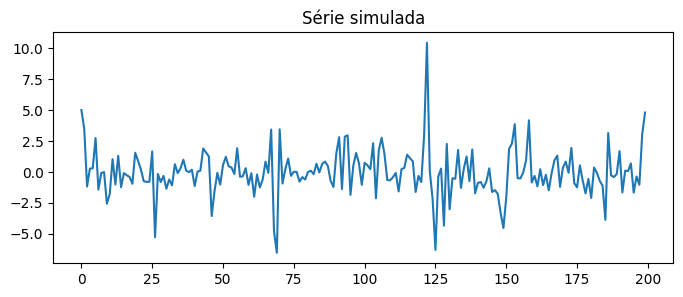

In [4]:
fig, ax = plt.subplots(figsize=(8,3))
ax.plot(np.arange(len(series)), series)
ax.set_title('Série simulada')
plt.show()

## i) k=3

### Simulação da densidade preditiva

In [5]:
k = 3
N = 10000

y_hat = np.zeros((T+k,N))

for t in range(T):
    y_curr = np.full(N, series[t])
    ϵt = rng.standard_t(df=ν, size=(k,N))
    
    for i in range(k):
        σ2_hat = ω + α * y_curr**2
        y_curr = σ2_hat**0.5 * ϵt[i]

    y_hat[t+k] = y_curr

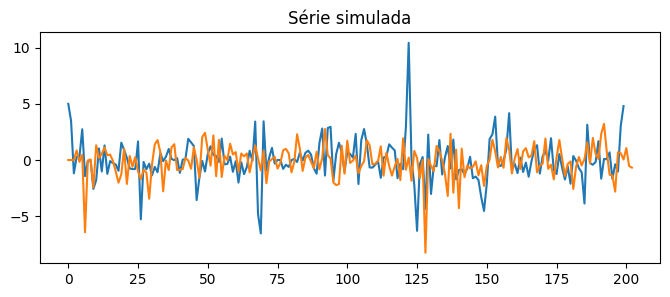

In [6]:
fig, ax = plt.subplots(figsize=(8,3))
ax.plot(np.arange(len(series)), series)
ax.plot(np.arange(len(y_hat)), y_hat[:,0])
ax.set_title('Série simulada')
plt.show()

### Histograma

Skewness: -0.47
Kurtosis: 21.28


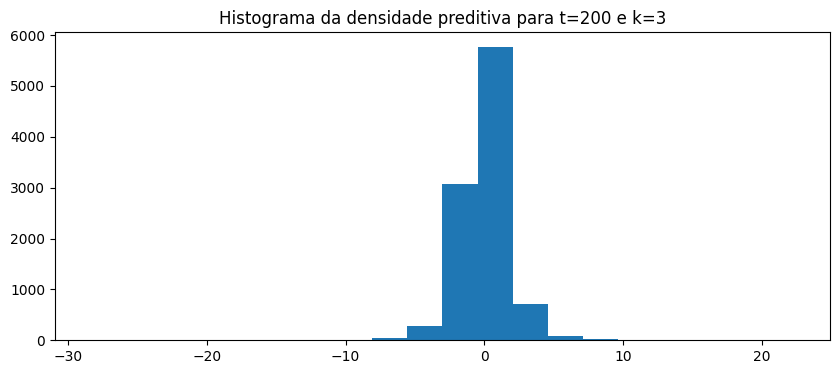

In [7]:
print(f'Skewness: {stats.skew(y_hat[T-1+k]):.2f}')
print(f'Kurtosis: {stats.kurtosis(y_hat[T-1+k]) + 3:.2f}')

fig, ax = plt.subplots(figsize=(10,4))
ax.hist(y_hat[T-1+k], bins=20)
ax.set_title('Histograma da densidade preditiva para t=200 e k=3')
plt.show()

## ii) k=30

### Simulação da densidade preditiva

In [8]:
k = 30
N = 10000

y_hat = np.zeros((T+k,N))

for t in range(T):
    y_curr = np.full(N, series[t])
    ϵt = rng.standard_t(df=ν, size=(k,N))
    
    for i in range(k):
        σ2_hat = ω + α * y_curr**2
        y_curr = σ2_hat**0.5 * ϵt[i]

    y_hat[t+k] = y_curr

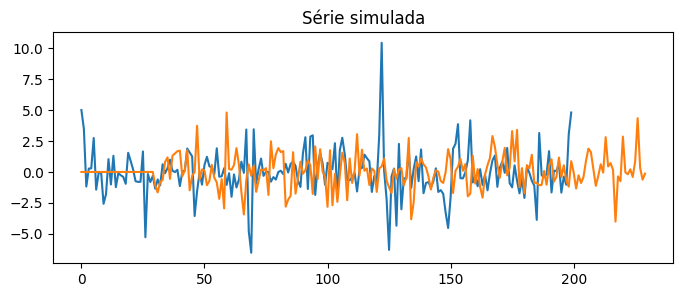

In [9]:
fig, ax = plt.subplots(figsize=(8,3))
ax.plot(np.arange(len(series)), series)
ax.plot(np.arange(len(y_hat)), y_hat[:,0])
ax.set_title('Série simulada')
plt.show()

### Histograma

Skewness: 0.02
Kurtosis: 8.27


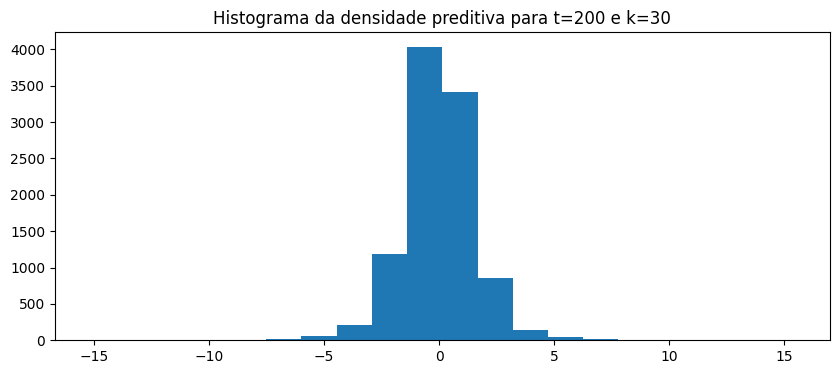

In [10]:
print(f'Skewness: {stats.skew(y_hat[T-1+k]):.2f}')
print(f'Kurtosis: {stats.kurtosis(y_hat[T-1+k]) + 3:.2f}')

fig, ax = plt.subplots(figsize=(10,4))
ax.hist(y_hat[T-1+k], bins=20)
ax.set_title('Histograma da densidade preditiva para t=200 e k=30')
plt.show()

# 2) Estimação do modelo

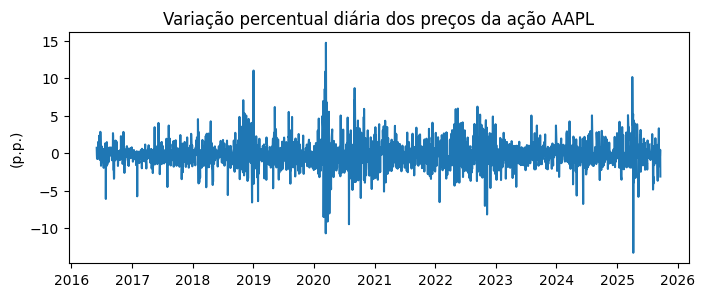

In [77]:
series = pd.read_csv('C:\\Users\\aless\\Downloads\\Apple Stock Price History.csv')[['Date','Price']].set_index('Date')
series.index = pd.to_datetime(series.index)

returns = series.pct_change().mul(100).dropna().loc['2016-06':]

fig, ax = plt.subplots(figsize=(8,3))
ax.plot(returns)
ax.set_title('Variação percentual diária dos preços da ação AAPL')
ax.set_ylabel('(p.p.)')
plt.savefig('C:\\Users\\aless\\Desktop\\Codes\\masters\\SDM\\img\\retornos.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [69]:
model = arch_model(returns, vol='GARCH', p=1, q=0, dist='t', mean='Constant')

res = model.fit(disp='off')
print(res.summary())

                         Constant Mean - ARCH Model Results                         
Dep. Variable:                        Price   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                             ARCH   Log-Likelihood:               -4453.71
Distribution:      Standardized Student's t   AIC:                           8915.41
Method:                  Maximum Likelihood   BIC:                           8938.44
                                              No. Observations:                 2339
Date:                      Sun, Sep 21 2025   Df Residuals:                     2338
Time:                              15:36:40   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu     

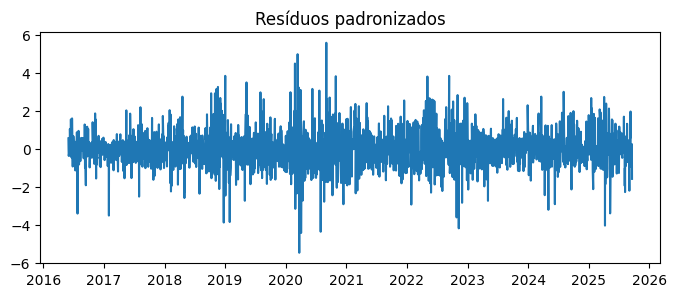

In [78]:
std_resid = res.std_resid.dropna()

fig, ax = plt.subplots(figsize=(8,3))
ax.plot(std_resid)
ax.set_title('Resíduos padronizados')
plt.savefig('C:\\Users\\aless\\Desktop\\Codes\\masters\\SDM\\img\\resíduos.jpg', dpi=300, bbox_inches='tight')
plt.show()

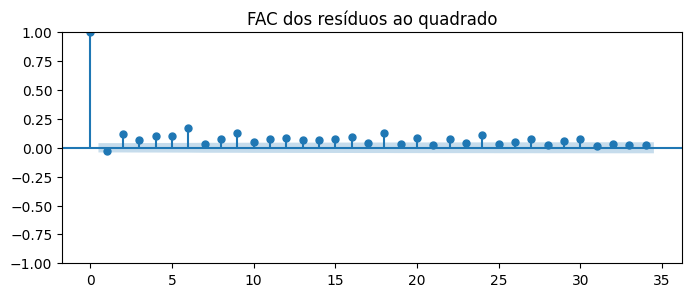

In [79]:
fig, ax = plt.subplots(figsize=(8,3))
plot_acf(std_resid**2, ax=ax, title='FAC dos resíduos ao quadrado')
plt.savefig('C:\\Users\\aless\\Desktop\\Codes\\masters\\SDM\\img\\FAC.jpg', dpi=300, bbox_inches='tight')
plt.show()

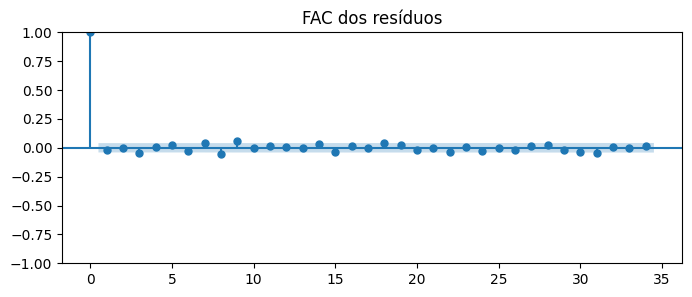

In [88]:
fig, ax = plt.subplots(figsize=(8,3))
plot_acf(std_resid, ax=ax, title='FAC dos resíduos')
plt.savefig('C:\\Users\\aless\\Desktop\\Codes\\masters\\SDM\\img\\FAC linear.jpg', dpi=300, bbox_inches='tight')
plt.show()